In [1]:
import pandas as pd
import numpy as np
 

In [2]:
# ============================================================
# Step 1: Load Preprocessed and Scaled Dataset
# ============================================================
# Using corrected training-only scaling pipeline
# to prevent data leakage.

base_path = "TELCO_MODEL"

X_train = pd.read_csv(f"{base_path}/X_train_scaled_v2.csv")
X_test = pd.read_csv(f"{base_path}/X_test_scaled_v2.csv")
y_train = pd.read_csv(f"{base_path}/y_train.csv").values.ravel()
y_test = pd.read_csv(f"{base_path}/y_test.csv").values.ravel()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (5392, 10)
y_train shape: (5392,)


In [3]:
# ============================================================
# Step 2: Define ANN Architecture
# ============================================================
# Input Layer: 10 features
# Hidden Layer 1: 64 neurons (ReLU)
# Hidden Layer 2: 32 neurons (ReLU)
# Output Layer: Binary classification (Churn / No Churn)
# Optimizer: Adam
# Early stopping enabled to prevent overfitting

from sklearn.neural_network import MLPClassifier


In [4]:
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',              
    max_iter=500,               
    early_stopping=True,        
    validation_fraction=0.1,    
    n_iter_no_change=10,        
    random_state=42
)



In [5]:
# ============================================================
# Step 3: Train ANN Model on Training Dataset
# ============================================================
# Model is trained using only training data.
# Validation monitored using early stopping.
model.fit(X_train, y_train)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [6]:
# ============================================================
# Step 4: Evaluate Model Performance
# ============================================================
# Metrics calculated:
# - Accuracy
# - Precision
# - Recall
# - F1-score

accuracy = model.score(X_test, y_test)
print("Test Accuracy:", accuracy)



Test Accuracy: 0.7865085248332098


In [7]:
print("Final Training Loss:", model.loss_)


Final Training Loss: 0.43017766018087833


In [8]:
# 1️⃣ 生成预测类别
y_pred = model.predict(X_test)

# 2️⃣ 生成 churn 概率
y_prob = model.predict_proba(X_test)[:, 1]

print("Sample probabilities:", y_prob[:5])

Sample probabilities: [0.20578536 0.09022529 0.02189701 0.64235139 0.05042548]


In [9]:
print("y_pred shape:", y_pred.shape)
# ============================================================
# Confusion Matrix Analysis
# ============================================================
# Visualizes True Positives, True Negatives,
# False Positives and False Negatives.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

y_pred shape: (1349,)
Accuracy : 0.7865085248332098
Precision: 0.6422764227642277
Recall   : 0.441340782122905
F1-score : 0.5231788079470199


In [10]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       991
           1       0.64      0.44      0.52       358

    accuracy                           0.79      1349
   macro avg       0.73      0.68      0.69      1349
weighted avg       0.77      0.79      0.77      1349



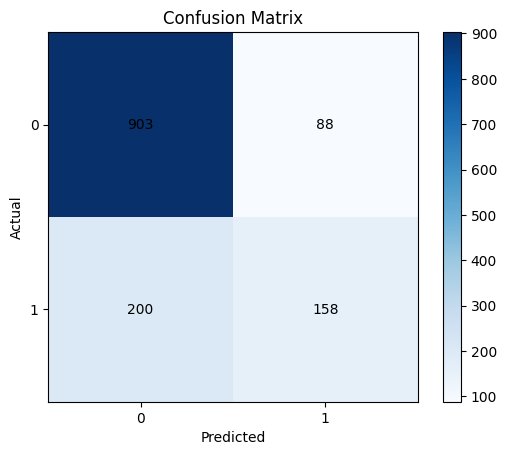

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.xticks([0,1])
plt.yticks([0,1])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [12]:
# 调整阈值为 0.3
y_pred_03 = (y_prob > 0.3).astype(int)

from sklearn.metrics import recall_score, precision_score, f1_score

print("New Precision:", precision_score(y_test, y_pred_03))
print("New Recall   :", recall_score(y_test, y_pred_03))
print("New F1       :", f1_score(y_test, y_pred_03))

New Precision: 0.5144628099173554
New Recall   : 0.6955307262569832
New F1       : 0.5914489311163895


In [13]:
import joblib

# 保存模型
joblib.dump(model, "ann_mlp_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [14]:
import os
print(os.listdir())

['2024', 'Ada-Dai-BA-Resume.pdf', 'Ada-Dai-Resume.pdf', 'ai', 'ANN Architecture Design for Telco Customer Churn Prediction.docx', 'ann_mlp_model.pkl', 'ann_training_script.ipynb', 'AU Pillow case backdrop design catalog.pdf', 'cv', 'DeepL.lnk', 'desktop.ini', 'Docker Desktop.lnk', 'Documents', 'Guardian Browser.lnk', 'Insomnia.lnk', 'LX Music.lnk', 'lx-music-desktop', 'Microsoft Edge.lnk', 'Module 2 group1.pptx', 'Music', 'n2ttools', 'OVHCDOHALETTER.pdf', 'passport.pdf', 'pathfinder.py', 'Pictures', 'QuickFox.lnk', 'Support-LogMeInRescue.exe', 'Telco_Model', 'usml', 'Veee', 'Videos', 'Visual Studio Code.lnk', 'WPS Office.lnk', 'xinyun - Chrome.lnk', 'Xinyun Dai placement.docx', 'Xinyun Dai-SFIAAssessment Document.docx', 'Zoom Workplace.lnk', '~$20小组作业.docx', '~$IA NOTEBOOK(1).docx', '~$nyun Dai placement.docx', '~$ssay框架.docx', '~$tebook 2007 Asia.docx', '~$周一演讲.docx', '~$周一演讲.pptx', '~$开仓表格.xlsx', '~$文化笔记中文版.docx', '~$方言语音.docx', '~$稿子.docx', '壁纸.jpg', '开仓表格.xlsx', '测试的文件.pdf', '白底屏幕截

In [22]:
import joblib

joblib.dump(model, "TELCO_MODEL/ann_mlp_model.pkl")
print("Model saved successfully.")

import os

base_path = "TELCO_MODEL"

model_path = os.path.join(base_path, "ann_mlp_model.pkl")

loaded_model = joblib.load(model_path)
print("Model loaded successfully.")

Model saved successfully.
Model loaded successfully.


In [23]:

from sklearn.metrics import accuracy_score

print("Loaded model accuracy:",
      accuracy_score(y_test, y_pred_loaded))

Loaded model accuracy: 0.7865085248332098


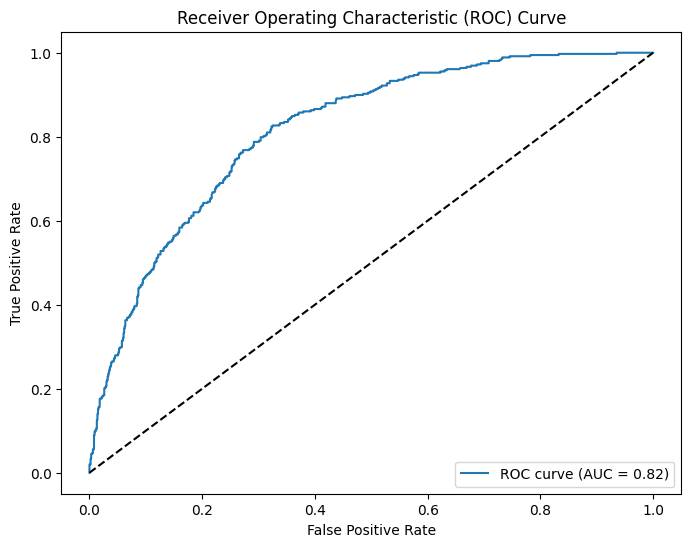

In [17]:
# ============================================================
# Step 5: ROC-AUC Robustness Analysis
# ============================================================
# ROC curve evaluates performance across thresholds.
# AUC measures overall robustness of classification.
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. 获取预测概率（注意：这里需要用 predict_proba，而不是 predict）
# 假设是二分类，获取正类（类别1）的概率
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. 计算 ROC 曲线的指标
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# 3. 绘图
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # 对角线
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()